# Relação entre CVLI, IDH, população e presença de facções em Fortaleza

**Autores:** Arthur Thomé Costa, Clara Lima Silva, Mateus Rodrigues da Silva, Miguel de Lima Amaral.

## Pergunta de pesquisa

Este trabalho investiga a relação entre os índices de **Crimes Violentos Letais e Intencionais (CVLI)**, indicadores de **vulnerabilidade socioeconômica** (IDH de 2010 e renda média de 2022) e a **presença de facções criminosas** nos bairros de Fortaleza, com o objetivo de compreender as implicações do chamado *estado paralelo* na vida dos cidadãos fortalezenses.

**Hipótese exploratória:** áreas com menor IDH, menor renda e maior presença documentada de facções tendem a concentrar taxas mais elevadas de CVLI.

**Fontes de dados:**
- CVLI (SSPDS/CE), 2009–2025
- IDH e população por bairro (Fortaleza Dados Abertos / Censo 2010)
- **Renda média mensal do responsável pelo domicílio por bairro (Censo 2022)** — IPECE, Informe nº 272
- **IDHM 2024** (Ceará 0,773; RMF Fortaleza 0,796) — PNUD/Radar IDHM, como contexto macro
- Presença de facções (notícias e relatórios públicos codificados manualmente)
- Mapeamento AIS ↔ bairros (SUPESP/SSPDS, Portaria 34/2026)

> **Nota metodológica:** IDH e população referem-se a 2010; a renda por bairro, a 2022; o CVLI vai até 2025. A análise espacial usa **AIS** (Áreas Integradas de Segurança), pois o registro individual de CVLI não traz o bairro da ocorrência. O IDHM 2024 não está disponível por bairro/AIS e é usado apenas como referência municipal/regional.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 13, "axes.labelsize": 11})

DATA_DIR = Path("dados")
print("Diretório de dados:", DATA_DIR.resolve())


Diretório de dados: /home/clarals/Documentos/TRABALHO EA/dados


## 1. Carregamento e limpeza do CVLI


In [2]:
cvli_raw = pd.read_excel(DATA_DIR / "CVLI_2009-a-2025.xlsx", sheet_name="CVLI")
print("Dimensão original:", cvli_raw.shape)
cvli_raw.head()


Dimensão original: (59340, 11)


,Município,AIS,Natureza,Data,Hora,Dia da Semana,Meio Empregado,Gênero,Idade da Vítima,Escolaridade da Vítima,Raça da Vítima
0,Fortaleza,AIS 20,HOMICIDIO DOLOSO,2009-01-01,00:00:00,Quinta,Outros meios,Masculino,Não Informada,Não Informada,Não Informada
1,Carnaubal,AIS 27,HOMICIDIO DOLOSO,2009-01-01,00:00:00,Quinta,Outros meios,Masculino,Não Informada,Não Informada,Não Informada
2,Quixadá,AIS 09,HOMICIDIO DOLOSO,2009-01-01,00:00:00,Quinta,Arma de fogo,Masculino,Não Informada,Não Informada,Não Informada
3,Baturité,AIS 29,HOMICIDIO DOLOSO,2009-01-01,00:00:00,Quinta,Arma de fogo,Masculino,Não Informada,Não Informada,Não Informada
4,Maracanaú,AIS 14,HOMICIDIO DOLOSO,2009-01-01,00:00:00,Quinta,Arma de fogo,Masculino,Não Informada,Não Informada,Não Informada


In [3]:
print("Valores nulos por coluna (antes da limpeza — base completa):")
print(cvli_raw.isna().sum())

cvli_fortaleza_bruto = cvli_raw[cvli_raw["Município"] == "Fortaleza"].copy()
print(f"\nRegistros de Fortaleza na base bruta: {len(cvli_fortaleza_bruto):,}")
print("\nValores nulos por coluna (antes da limpeza — só Fortaleza):")
print(cvli_fortaleza_bruto.isna().sum())


Valores nulos por coluna (antes da limpeza — base completa):
Município                 0
AIS                       0
Natureza                  0
Data                      0
Hora                      0
Dia da Semana             0
Meio Empregado            0
Gênero                    0
Idade da Vítima           0
Escolaridade da Vítima    0
Raça da Vítima            0
dtype: int64

Registros de Fortaleza na base bruta: 21,256

Valores nulos por coluna (antes da limpeza — só Fortaleza):
Município                 0
AIS                       0
Natureza                  0
Data                      0
Hora                      0
Dia da Semana             0
Meio Empregado            0
Gênero                    0
Idade da Vítima           0
Escolaridade da Vítima    0
Raça da Vítima            0
dtype: int64


**Observação**: na base da SSPDS, muitos campos ausentes já vêm como "Não Informada" em vez de NaN — por isso os dois blocos podem mostrar 0 nulos. A diferença principal entre antes e depois está na quantidade de registros (21.256 → 21.197), pelos filtros de natureza do crime e AIS identificada.

In [4]:
cvli = cvli_raw[cvli_raw["Município"] == "Fortaleza"].copy()
cvli["Data"] = pd.to_datetime(cvli["Data"], errors="coerce")
cvli["ano"] = cvli["Data"].dt.year
cvli["mes"] = cvli["Data"].dt.month
cvli["ais_num"] = (
    cvli["AIS"].astype(str).str.extract(r"(\d+)")[0].astype("Int64")
)

naturezas_cvli = [
    "HOMICIDIO DOLOSO",
    "ROUBO SEGUIDO DE MORTE (LATROCINIO)",
    "LESAO CORPORAL SEGUIDA DE MORTE",
]
cvli = cvli[cvli["Natureza"].isin(naturezas_cvli)]
cvli = cvli[cvli["ais_num"].notna()]

for col in ["Idade da Vítima", "Escolaridade da Vítima", "Raça da Vítima"]:
    cvli[col] = cvli[col].fillna("Não Informada")

print("Registros em Fortaleza (CVLI):", len(cvli))
print("Período:", int(cvli["ano"].min()), "–", int(cvli["ano"].max()))
print("AIS distintas:", sorted(cvli["ais_num"].dropna().unique().tolist()))
cvli[["AIS", "Natureza", "Data", "Meio Empregado", "Gênero"]].head()


Registros em Fortaleza (CVLI): 21197
Período: 2009 – 2025
AIS distintas: [5, 6, 8, 16, 17, 18, 19, 20, 21, 22]


,AIS,Natureza,Data,Meio Empregado,Gênero
0,AIS 20,HOMICIDIO DOLOSO,2009-01-01,Outros meios,Masculino
6,AIS 22,HOMICIDIO DOLOSO,2009-01-01,Arma de fogo,Masculino
7,AIS 08,HOMICIDIO DOLOSO,2009-01-01,Arma de fogo,Masculino
8,AIS 20,HOMICIDIO DOLOSO,2009-01-01,Arma de fogo,Masculino
12,AIS 17,HOMICIDIO DOLOSO,2009-01-01,Arma branca,Masculino


In [5]:
print("Valores nulos por coluna (após limpeza):")
print(cvli.isna().sum())
print("\nDescrição do perfil das vítimas:")
print(cvli[["Gênero", "Meio Empregado", "Natureza"]].describe(include="all"))


Valores nulos por coluna (após limpeza):
Município                 0
AIS                       0
Natureza                  0
Data                      0
Hora                      0
Dia da Semana             0
Meio Empregado            0
Gênero                    0
Idade da Vítima           0
Escolaridade da Vítima    0
Raça da Vítima            0
ano                       0
mes                       0
ais_num                   0
dtype: int64

Descrição do perfil das vítimas:
           Gênero Meio Empregado          Natureza
count       21197          21197             21197
unique          3              4                 3
top     Masculino   Arma de fogo  HOMICIDIO DOLOSO
freq        19756          18900             20506


## 2. Agregação do CVLI por ano e por AIS


In [6]:
cvli_ano = (
    cvli.groupby("ano", as_index=False)
    .size()
    .rename(columns={"size": "cvli_total"})
    .sort_values("ano")
)
cvli_ano


,ano,cvli_total
0,2009,979
1,2010,1236
2,2011,1238
3,2012,1702
4,2013,1994
5,2014,2002
6,2015,1653
7,2016,1012
8,2017,1982
9,2018,1475


In [7]:
cvli_ais = (
    cvli.groupby("ais_num", as_index=False)
    .agg(
        cvli_total=("Natureza", "size"),
        homicidios=("Natureza", lambda s: (s == "HOMICIDIO DOLOSO").sum()),
        arma_fogo=("Meio Empregado", lambda s: (s == "Arma de fogo").sum()),
        outros_meios=("Meio Empregado", lambda s: (s != "Arma de fogo").sum()),
    )
    .rename(columns={"ais_num": "ais"})
    .sort_values("cvli_total", ascending=False)
)
cvli_ais


,ais,cvli_total,homicidios,arma_fogo,outros_meios
3,16,3151,3075,2832,319
4,17,2796,2733,2530,266
8,21,2728,2642,2434,294
6,19,2702,2640,2469,233
5,18,2578,2479,2296,282
7,20,2426,2362,2196,230
1,6,1582,1490,1388,194
0,5,1200,1123,962,238
9,22,1061,1026,943,118
2,8,973,936,850,123


## 3. Integração com IDH, população e facções


In [8]:
def normalizar_bairro(nome: str) -> str:
    if pd.isna(nome):
        return ""
    nome = str(nome).strip()
    substituicoes = {
        "Estância (Dionísio Torres)": "Dionísio Torres",
        "Vila Pery": "Vila Peri",
        "PanAmericano": "Panamericano",
        "Pan Americano": "Panamericano",
        "Vila Manoel Sátiro": "Manoel Sátiro",
        "Vila Ellery": "Ellery",
        "São João do Tauape": "São João do Tauape",
        "Boa Vista": "Boa Vista / Castelão",
        "Sapiranga": "Sapiranga / Coité",
        "Sapiranga/Coité": "Sapiranga / Coité",
        "Tauape": "São João do Tauape",
        "Lourdes": "De Lourdes",
        "Amadeo Furtado": "Amadeu Furtado",
        "Arraial Moura Brasil": "Moura Brasil",
        "Dias Macêdo": "Dias Macedo",
        "Guajerú": "Guajeru",
        "Luciano Cavalcante": "Engenheiro Luciano Cavalcante",
        "Novo Mondubim*": "Novo Mondubim",
        "Olavo Oliveira*": "Olavo Oliveira",
        "Parque Santa Maria*": "Parque Santa Maria",
        "Pirambú": "Pirambu",
        "Prefeito José Valter": "Prefeito José Walter",
        "Vincente Pinzon": "Vicente Pinzón",
        "Dendê (Rachel de Queiroz)": "Dendê",
    }
    return substituicoes.get(nome, nome)

pop_raw = pd.read_excel(DATA_DIR / "populacao_por_bairro.xlsx", header=2)
pop = pop_raw.rename(columns={"Bairros": "bairro", "População Total": "populacao"})
pop = pop[["bairro", "populacao"]].dropna(subset=["bairro"])
pop["bairro_norm"] = pop["bairro"].map(normalizar_bairro)
pop["populacao"] = pd.to_numeric(pop["populacao"], errors="coerce")

idh = pd.read_excel(DATA_DIR / "idh_por_bairro.xlsx")
idh = idh.rename(columns={"Bairros": "bairro", "IDH": "idh"})
idh["bairro_norm"] = idh["bairro"].map(normalizar_bairro)
idh["idh"] = pd.to_numeric(idh["idh"], errors="coerce")

renda = pd.read_csv(DATA_DIR / "renda_por_bairro_2022.csv")
renda["bairro_norm"] = renda["bairro"].map(normalizar_bairro)
renda["renda_media_2022"] = pd.to_numeric(renda["renda_media_responsavel_2022"], errors="coerce")

ais_map = pd.read_csv(DATA_DIR / "ais_bairros.csv")
ais_map["bairro_norm"] = ais_map["bairro"].map(normalizar_bairro)

faccoes = pd.read_excel(DATA_DIR / "faccoes_bairros.xlsx", sheet_name="faccoes_bairros")
faccoes["bairro_norm"] = faccoes["bairro"].map(normalizar_bairro)

print(
    "Bairros população:", len(pop),
    "| IDH:", len(idh),
    "| Renda 2022:", len(renda),
    "| AIS map:", len(ais_map),
)


Bairros população: 120 | IDH: 123 | Renda 2022: 121 | AIS map: 123


In [9]:
bairros = (
    pop.merge(idh[["bairro_norm", "idh"]], on="bairro_norm", how="outer")
    .merge(renda[["bairro_norm", "renda_media_2022"]], on="bairro_norm", how="outer")
    .merge(ais_map[["bairro_norm", "ais"]], on="bairro_norm", how="left")
)
bairros["populacao"] = bairros["populacao"].fillna(0)

faccoes_agg = (
    faccoes.groupby("bairro_norm", as_index=False)
    .agg(
        tem_faccao=("faccao", "size"),
        faccao_principal=("faccao", "first"),
    )
)
faccoes_agg["tem_faccao"] = 1

bairros = bairros.merge(faccoes_agg, on="bairro_norm", how="left")
bairros["tem_faccao"] = bairros["tem_faccao"].fillna(0).astype(int)


def media_ponderada(serie, pesos):
    df = pd.DataFrame({"v": serie, "w": pesos}).dropna(subset=["v", "w"])
    df = df[df["w"] > 0]
    if len(df) == 0:
        return np.nan
    return np.average(df["v"], weights=df["w"])


ais_socio = (
    bairros.groupby("ais", as_index=False)
    .apply(
        lambda g: pd.Series(
            {
                "populacao": g["populacao"].sum(),
                "idh": media_ponderada(g["idh"], g["populacao"]),
                "renda_media_2022": media_ponderada(g["renda_media_2022"], g["populacao"]),
                "bairros_com_faccao": g["tem_faccao"].sum(),
                "tem_faccao": int(g["tem_faccao"].max()),
                "faccao_principal": g.loc[g["tem_faccao"] == 1, "faccao_principal"].mode().iloc[0]
                if g["tem_faccao"].any()
                else "Sem registro",
            }
        ),
        include_groups=False,
    )
    .reset_index(drop=True)
)

base = ais_socio.merge(cvli_ais, on="ais", how="inner")
base["taxa_cvli_100k"] = base["cvli_total"] / base["populacao"] * 100_000
base = base.sort_values("taxa_cvli_100k", ascending=False).reset_index(drop=True)
base["ranking_taxa"] = base["taxa_cvli_100k"].rank(ascending=False, method="min").astype(int)

# Contexto macro IDHM 2024 (PNUD) — não disponível por AIS
IDHM_CEARA_2024 = 0.773
IDHM_RMF_FORTALEZA_2024 = 0.796

base.round({"idh": 3, "renda_media_2022": 0, "taxa_cvli_100k": 1})


,ais,populacao,idh,renda_media_2022,bairros_com_faccao,tem_faccao,faccao_principal,cvli_total,homicidios,arma_fogo,outros_meios,taxa_cvli_100k,ranking_taxa
0,16.0,256096.0,0.221,1914.0,4,1,CV,3151,3075,2832,319,1230.4,1
1,17.0,246309.0,0.202,1554.0,7,1,CV,2796,2733,2530,266,1135.2,2
2,20.0,245531.0,0.250,1695.0,3,1,CV,2426,2362,2196,230,988.1,3
3,19.0,285064.0,0.329,3212.0,4,1,CV,2702,2640,2469,233,947.9,4
4,21.0,295202.0,0.248,1945.0,8,1,GDE/CV,2728,2642,2434,294,924.1,5
5,5.0,154782.0,0.437,3099.0,0,0,Sem registro,1200,1123,962,238,775.3,6
6,18.0,360551.0,0.333,2258.0,3,1,CV,2578,2479,2296,282,715.0,7
7,22.0,162327.0,0.575,6803.0,2,1,CV,1061,1026,943,118,653.6,8
8,8.0,172541.0,0.645,7134.0,1,1,CV,973,936,850,123,563.9,9
9,6.0,281645.0,0.436,3279.0,2,1,CV/GDE,1582,1490,1388,194,561.7,10


### Renda média por bairro (Censo 2022) e contexto IDHM 2024

O **IPECE Informe nº 272** (Censo 2022) mostra forte desigualdade intraurbana em Fortaleza: a renda média mensal do responsável pelo domicílio varia de **R$ 1.272,25** (Genibaú) a **R$ 14.775,21** (Guararapes), com mediana municipal de **R$ 2.229,66**. Cerca de **33%** da população vive em bairros do 1º quartil de renda (até R$ 1.739,54).

No nível das AIS, agregamos a renda por **média ponderada pela população** dos bairros. O **Radar IDHM 2024** (PNUD) indica IDHM de **0,773** para o Ceará e **0,796** para a RMF de Fortaleza — valores agregados que confirmam melhora macro desde 2010, mas **não substituem** o IDH por bairro (2010) nem a renda por bairro (2022) nesta análise.

A tabela abaixo cruza renda 2022 com IDH 2010 e taxa de CVLI nas AIS mais relevantes.

In [10]:
base[[
    "ais", "populacao", "idh", "renda_media_2022", "cvli_total", "taxa_cvli_100k",
    "tem_faccao", "bairros_com_faccao",
]].sort_values("taxa_cvli_100k", ascending=False).round({"idh": 3, "renda_media_2022": 0, "taxa_cvli_100k": 1})

,ais,populacao,idh,renda_media_2022,cvli_total,taxa_cvli_100k,tem_faccao,bairros_com_faccao
0,16.0,256096.0,0.221,1914.0,3151,1230.4,1,4
1,17.0,246309.0,0.202,1554.0,2796,1135.2,1,7
2,20.0,245531.0,0.250,1695.0,2426,988.1,1,3
3,19.0,285064.0,0.329,3212.0,2702,947.9,1,4
4,21.0,295202.0,0.248,1945.0,2728,924.1,1,8
5,5.0,154782.0,0.437,3099.0,1200,775.3,0,0
6,18.0,360551.0,0.333,2258.0,2578,715.0,1,3
7,22.0,162327.0,0.575,6803.0,1061,653.6,1,2
8,8.0,172541.0,0.645,7134.0,973,563.9,1,1
9,6.0,281645.0,0.436,3279.0,1582,561.7,1,2


### Codificação de facções e links das fontes

A tabela abaixo resume os **39 registros** de **34 bairros** com presença documentada de facções (CV, GDE, TCP ou disputas entre elas). Com a base ampliada, **9 das 10 AIS** analisadas têm ao menos um bairro codificado; apenas a **AIS 5** (Centro) permanece sem registro. Cada linha traz a **fonte**, o **ano** e o **link** da matéria ou relatório. O arquivo completo está em `dados/faccoes_bairros.xlsx` (abas `faccoes_bairros` e `ais_relevantes`).

**Critérios:** menções explícitas a domínio territorial, operações policiais ou mapeamento oficial que identifiquem o bairro. Fontes: O Povo, Diário do Nordeste, G1 Ceará, Polícia Civil, Folha, Fortaleza Dados Abertos.


In [11]:
faccoes[["bairro", "ais", "faccao", "tipo_evidencia", "fonte", "ano_referencia", "link"]].sort_values(["ais", "bairro"])


,bairro,ais,faccao,tipo_evidencia,fonte,ano_referencia,link
30,Parangaba,6,GDE,noticia,O Povo — mapeamento Annulare,2021,https://mais.opovo.com.br/jornal/reportagem/20...
29,Vila União,6,CV/GDE,noticia,O Povo — disputa CV x GDE no Vila União,2025,https://www.opovo.com.br/noticias/ceara/2025/0...
36,Vicente Pinzón,8,CV,noticia,O Povo — disputa CV no Lagamar/Vicente Pinzón,2025,https://www.opovo.com.br/noticias/ceara/2025/0...
10,Conjunto Palmeiras,16,CV/TCP,noticia,O Povo — homicídios e disputa TCP em fevereiro,2025,https://www.opovo.com.br/noticias/ceara/2025/1...
8,Jangurussu,16,TCP,noticia,O Povo — TCP expulsa famílias no Jangurussu,2025,https://www.opovo.com.br/noticias/fortaleza/20...
9,Jangurussu,16,CV/TCP,noticia,Folha — conjunto José Euclides tomado por facções,2026,https://www1.folha.uol.com.br/cotidiano/2026/0...
11,Messejana,16,CV,noticia,G1 — Operação Kleptonomos na Grande Messejana,2025,https://g1.globo.com/ce/ceara/noticia/2025/07/...
12,Messejana,16,CV,noticia,G1 — operação contra CV menciona Messejana,2025,https://g1.globo.com/ce/ceara/noticia/2025/09/...
13,Paupina,16,CV,noticia,G1 — operação CV em bairros do extremo sul,2025,https://g1.globo.com/ce/ceara/noticia/2025/09/...
6,Bom Jardim,17,CV,noticia,O Povo — festa do CV no Alto da Paz (Bom Jardim),2025,https://mais.opovo.com.br/jornal/cidades/2025/...


### AIS mais relevantes nas estatísticas (com bairros)

Tabela das AIS ordenadas por taxa de CVLI, com a **lista completa de bairros** de cada AIS e quais bairros têm facção documentada. Também disponível na aba `ais_relevantes` de `dados/faccoes_bairros.xlsx`.


In [12]:
ais_map_lista = (
    ais_map.groupby("ais")["bairro"]
    .apply(lambda s: ", ".join(sorted(s)))
    .reset_index(name="bairros_da_ais")
)
fac_por_ais = (
    faccoes.groupby("ais")["bairro"]
    .apply(lambda s: ", ".join(sorted(set(s))))
    .reset_index(name="bairros_com_faccao_documentada")
)
ais_relevantes = (
    base.merge(ais_map_lista, on="ais")
    .merge(fac_por_ais, on="ais", how="left")
    .sort_values("taxa_cvli_100k", ascending=False)
)
ais_relevantes["bairros_com_faccao_documentada"] = ais_relevantes["bairros_com_faccao_documentada"].fillna("Sem registro")
ais_relevantes[[
    "ais", "populacao", "idh", "renda_media_2022", "cvli_total", "taxa_cvli_100k",
    "tem_faccao", "bairros_com_faccao", "bairros_da_ais", "bairros_com_faccao_documentada"
]].round({"idh": 3, "renda_media_2022": 0, "taxa_cvli_100k": 1})


,ais,populacao,idh,renda_media_2022,cvli_total,taxa_cvli_100k,tem_faccao,bairros_com_faccao,bairros_da_ais,bairros_com_faccao_documentada
0,16.0,256096.0,0.221,1914.0,3151,1230.4,1,4,"Ancuri, Barroso, Coaçu, Conjunto Palmeiras, Cu...","Conjunto Palmeiras, Jangurussu, Messejana, Pau..."
1,17.0,246309.0,0.202,1554.0,2796,1135.2,1,7,"Bom Jardim, Conjunto Ceará I, Conjunto Ceará I...","Bom Jardim, Conjunto Ceará I, Conjunto Ceará I..."
2,20.0,245531.0,0.250,1695.0,2426,988.1,1,3,"Barra do Ceará, Cristo Redentor, Floresta, Jar...","Barra do Ceará, Cristo Redentor, Pirambu"
3,19.0,285064.0,0.329,3212.0,2702,947.9,1,4,"Aerolândia, Alto da Balança, Boa Vista / Caste...","Cambeba, Jardim das Oliveiras, Passaré, Sapira..."
4,21.0,295202.0,0.248,1945.0,2728,924.1,1,8,"Aracapé, Canindezinho, Conjunto Esperança, Jar...","Canindezinho, Maraponga, Mondubim, Parque Pres..."
5,5.0,154782.0,0.437,3099.0,1200,775.3,0,0,"Carlito Pamplona, Centro, Ellery, Farias Brito...",Sem registro
6,18.0,360551.0,0.333,2258.0,2578,715.0,1,3,"Amadeu Furtado, Antônio Bezerra, Autran Nunes,...","Bonsucesso, João XXIII, Pici"
7,22.0,162327.0,0.575,6803.0,1061,653.6,1,2,"Cidade 2000, Cocó, De Lourdes, Dionísio Torres...","Praia do Futuro II, São João do Tauape"
8,8.0,172541.0,0.645,7134.0,973,563.9,1,1,"Aldeota, Cais do Porto, Meireles, Mucuripe, Pr...",Vicente Pinzón
9,6.0,281645.0,0.436,3279.0,1582,561.7,1,2,"Aeroporto, Benfica, Bom Futuro, Couto Fernande...","Parangaba, Vila União"


## 4. Gráficos e cruzamentos


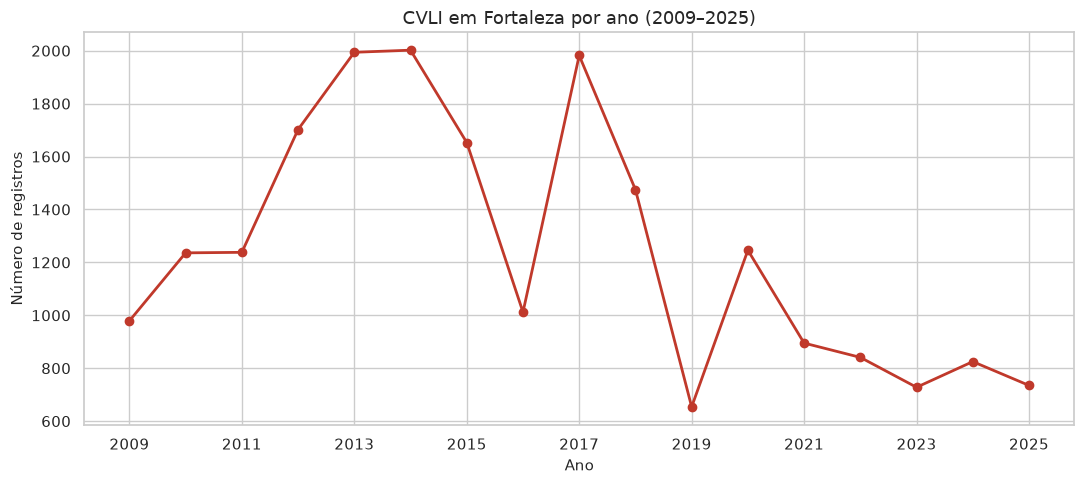

In [13]:
# Gráfico 1 — Série temporal
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cvli_ano["ano"], cvli_ano["cvli_total"], marker="o", linewidth=2, color="#c0392b")
ax.set_title("CVLI em Fortaleza por ano (2009–2025)")
ax.set_xlabel("Ano")
ax.set_ylabel("Número de registros")
ax.set_xticks(cvli_ano["ano"][::2])
plt.tight_layout()
plt.show()


**Interpretação (Gráfico 1):** Entre 2009 e 2014, os CVLIs em Fortaleza subiram de cerca de 980 para mais de 2.000 registros por ano, com pico em 2014. Após oscilações em 2015–2018, houve queda acentuada em 2019 (654 casos — o menor valor da série) e, desde então, os números se estabilizaram entre 700 e 1.250 casos anuais. Essa queda abrupta em 2019 pode refletir mudanças metodológicas de registro, efeitos de políticas de segurança ou disputas entre facções — hipóteses que esta análise descritiva não permite confirmar isoladamente.


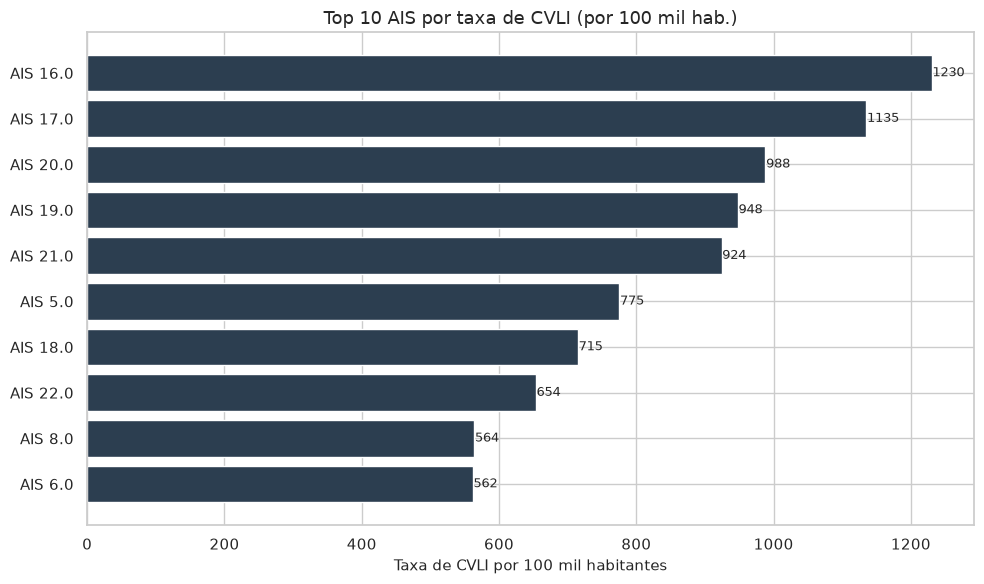

In [14]:
# Gráfico 2 — Taxa de CVLI por AIS em Fortaleza (todas as 10 AIS do município)
ais_por_taxa = base.sort_values("taxa_cvli_100k")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(ais_por_taxa["ais"].astype(str).radd("AIS "), ais_por_taxa["taxa_cvli_100k"], color="#2c3e50")
ax.set_title("Taxa de CVLI por AIS em Fortaleza (por 100 mil hab.)")
ax.set_xlabel("Taxa de CVLI por 100 mil habitantes")
for bar, val in zip(bars, ais_por_taxa["taxa_cvli_100k"]):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f"{val:.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Interpretação (Gráfico 2):** O gráfico apresenta as **10 AIS de Fortaleza** — cobertura integral do município na base da SSPDS (Portaria 34/2026), sem recorte analítico. As maiores taxas concentram-se na **AIS 16** (Messejana, Jangurussu — ~1.230/100 mil), **AIS 17** (Granja Lisboa, Conjunto Ceará — ~1.135/100 mil) e **AIS 20** (Barra do Ceará — ~988/100 mil), todas com facção documentada e IDH baixo. Destaca-se também a **AIS 5** (Centro e adjacências), que apresenta taxa elevada (~775/100 mil) **sem** registro de facção, mostrando que alta violência não se restringe exclusivamente às áreas com crime organizado codificado.


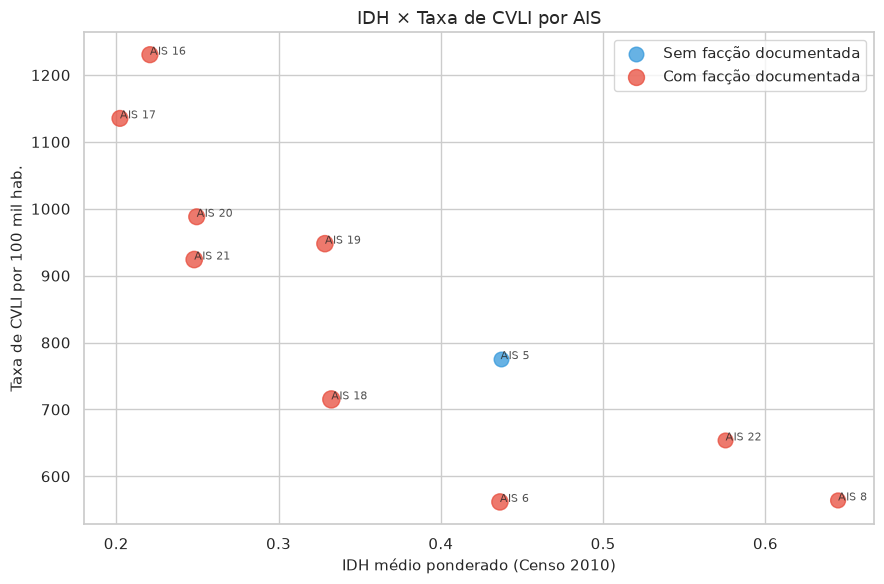

In [15]:
# Gráfico 3 — Dispersão IDH x taxa CVLI
fig, ax = plt.subplots(figsize=(9, 6))
palette = {0: "#3498db", 1: "#e74c3c"}
for flag, grp in base.groupby("tem_faccao"):
    ax.scatter(
        grp["idh"],
        grp["taxa_cvli_100k"],
        s=80 + grp["populacao"] / 5000,
        alpha=0.75,
        label="Com facção documentada" if flag else "Sem facção documentada",
        c=palette[flag],
    )
    for _, row in grp.iterrows():
        ax.annotate(f"AIS {int(row['ais'])}", (row["idh"], row["taxa_cvli_100k"]), fontsize=8, alpha=0.8)
ax.set_title("IDH × Taxa de CVLI por AIS")
ax.set_xlabel("IDH médio ponderado (Censo 2010)")
ax.set_ylabel("Taxa de CVLI por 100 mil hab.")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretação (Gráfico 3):** Há associação visual entre menor IDH e maior taxa de CVLI (Pearson ≈ −0,85; Spearman ≈ −0,85). As AIS com facção documentada (vermelho) concentram-se no quadrante de baixo IDH e alta violência — especialmente AIS 17, 19 e 20. Porém, existem exceções: a **AIS 6** (Parangaba e adjacências) tem facção codificada, mas taxa relativamente menor (~562/100 mil); já a **AIS 5** é a única sem facção registrada, mas ainda apresenta taxa elevada (~775/100 mil). Isso indica que o IDH e as facções explicam parte do padrão, mas não todo ele.


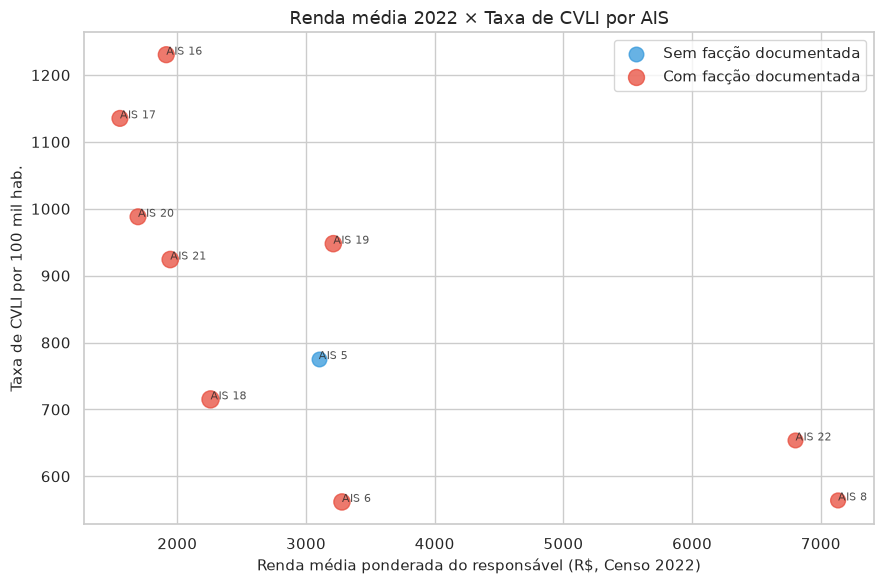

In [16]:
# Gráfico 3b — Dispersão Renda 2022 x taxa CVLI
fig, ax = plt.subplots(figsize=(9, 6))
palette = {0: "#3498db", 1: "#e74c3c"}
for flag, grp in base.groupby("tem_faccao"):
    ax.scatter(
        grp["renda_media_2022"],
        grp["taxa_cvli_100k"],
        s=80 + grp["populacao"] / 5000,
        alpha=0.75,
        label="Com facção documentada" if flag else "Sem facção documentada",
        c=palette[flag],
    )
    for _, row in grp.iterrows():
        ax.annotate(
            f"AIS {int(row['ais'])}",
            (row["renda_media_2022"], row["taxa_cvli_100k"]),
            fontsize=8,
            alpha=0.8,
        )
ax.set_title("Renda média 2022 × Taxa de CVLI por AIS")
ax.set_xlabel("Renda média ponderada do responsável (R$, Censo 2022)")
ax.set_ylabel("Taxa de CVLI por 100 mil hab.")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretação (Gráfico 3b):** A renda de 2022 — indicador mais recente que o IDH de 2010 — reproduz o padrão de concentração da violência nas AIS de menor capacidade econômica (Spearman renda × CVLI ≈ −0,84). Bairros como Genibaú (R$ 1.272), Bom Jardim (R$ 1.342) e Granja Lisboa (R$ 1.405) estão nas AIS de maior taxa de CVLI. A AIS 19 combina renda ponderada relativamente maior (R$ 3.212) com taxa ainda elevada (~948/100 mil), mostrando que renda e violência não se alinham perfeitamente em todos os casos.


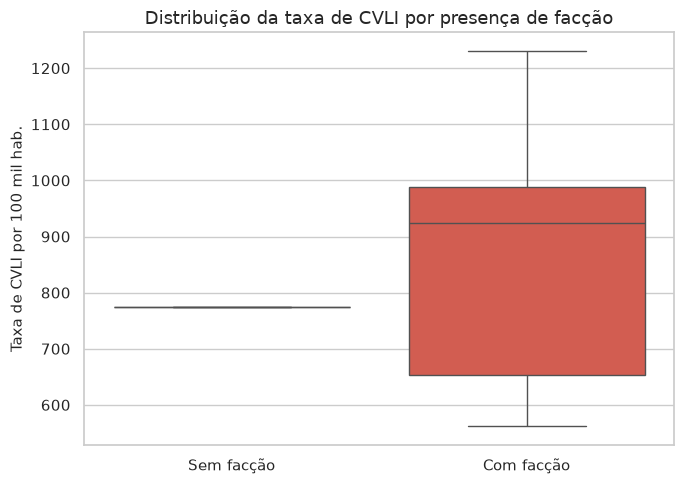

In [17]:
# Gráfico 4 — Boxplot com/sem facção
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=base, x="tem_faccao", y="taxa_cvli_100k", ax=ax,
            order=[0, 1], hue="tem_faccao", legend=False,
            palette=["#3498db", "#e74c3c"])
ax.set_xticklabels(["Sem facção", "Com facção"])
ax.set_title("Distribuição da taxa de CVLI por presença de facção")
ax.set_xlabel("")
ax.set_ylabel("Taxa de CVLI por 100 mil hab.")
plt.tight_layout()
plt.show()


**Interpretação (Gráfico 4):** A mediana da taxa de CVLI é maior nas AIS com facção documentada (mediana ≈ 924/100 mil, n = 9) do que na única AIS sem facção — **AIS 5** (≈ 775/100 mil). Contudo, com **9 AIS com facção e apenas 1 sem**, o teste de Mann-Whitney não indica diferença estatisticamente significativa (p ≈ 0,50). Visualmente há um padrão compatível com a hipótese, mas o desbalanceamento extremo dos grupos e o reduzido número de AIS (n = 10) impedem inferências robustas sobre o efeito isolado das facções.


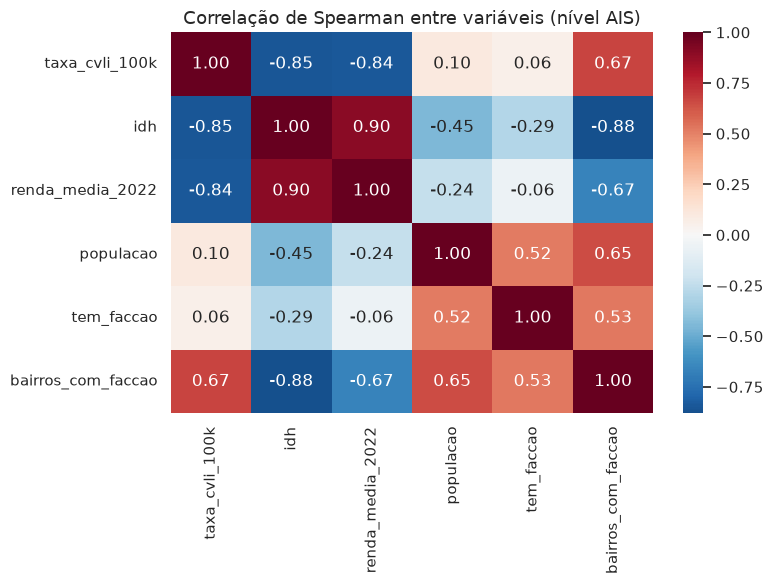

In [18]:
# Gráfico 5 — Heatmap de correlação
corr_cols = base[[
    "taxa_cvli_100k", "idh", "renda_media_2022", "populacao",
    "tem_faccao", "bairros_com_faccao",
]]
corr = corr_cols.corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlação de Spearman entre variáveis (nível AIS)")
plt.tight_layout()
plt.show()


**Interpretação (Gráfico 5):** O heatmap confirma correlações de Spearman fortemente negativas entre **renda (2022)** e taxa de CVLI (≈ −0,84) e entre **IDH (2010)** e taxa de CVLI (≈ −0,85), além de correlação positiva entre IDH e renda (≈ +0,90). A presença de facções correlaciona **fracamente** com a taxa de CVLI neste recorte (ρ ≈ +0,06), compatível com o fato de 9 das 10 AIS terem facção documentada. A correlação entre população e taxa permanece fraca (ρ ≈ +0,10).


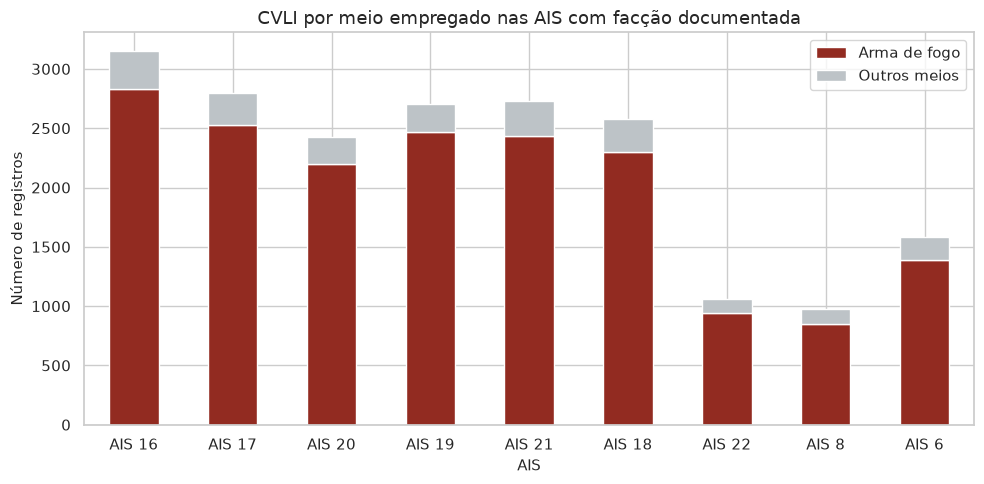

In [19]:
# Gráfico 6 — Meio empregado nas AIS com facção
# base já contém arma_fogo e outros_meios (via merge com cvli_ais)
fac_ais_plot = (
    base[base["tem_faccao"] == 1]
    .set_index("ais")[["arma_fogo", "outros_meios"]]
)
fac_ais_plot.index = fac_ais_plot.index.map(lambda x: f"AIS {int(x)}")
fac_ais_plot.plot(kind="bar", stacked=True, figsize=(10, 5), color=["#922b21", "#bdc3c7"])
plt.title("CVLI por meio empregado nas AIS com facção documentada")
plt.xlabel("AIS")
plt.ylabel("Número de registros")
plt.legend(["Arma de fogo", "Outros meios"], loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretação (Gráfico 6):** Nas **nove AIS** com facção documentada, cerca de **90%** dos CVLIs envolvem **arma de fogo** (~20 mil registros no total nessas áreas). Esse predomínio de armas de fogo é compatível com disputas territoriais entre grupos armados, característica central do controle exercido por facções nas comunidades.


In [20]:
# Cruzamentos estatísticos
pearson_idh = base["idh"].corr(base["taxa_cvli_100k"], method="pearson")
spearman_idh = base["idh"].corr(base["taxa_cvli_100k"], method="spearman")
pearson_renda = base["renda_media_2022"].corr(base["taxa_cvli_100k"], method="pearson")
spearman_renda = base["renda_media_2022"].corr(base["taxa_cvli_100k"], method="spearman")
spearman_idh_renda = base["idh"].corr(base["renda_media_2022"], method="spearman")

com = base[base["tem_faccao"] == 1]["taxa_cvli_100k"]
sem = base[base["tem_faccao"] == 0]["taxa_cvli_100k"]
stat, pvalor = stats.mannwhitneyu(com, sem, alternative="greater")

print(f"Correlação Pearson (IDH 2010 × taxa CVLI): {pearson_idh:.3f}")
print(f"Correlação Spearman (IDH 2010 × taxa CVLI): {spearman_idh:.3f}")
print(f"Correlação Pearson (Renda 2022 × taxa CVLI): {pearson_renda:.3f}")
print(f"Correlação Spearman (Renda 2022 × taxa CVLI): {spearman_renda:.3f}")
print(f"Correlação Spearman (IDH 2010 × Renda 2022): {spearman_idh_renda:.3f}")
print(f"Mann-Whitney (taxa CVLI: com vs sem facção): U={stat:.1f}, p={pvalor:.4f}")
print(f"\nContexto macro IDHM 2024 — Ceará: {IDHM_CEARA_2024:.3f} | RMF Fortaleza: {IDHM_RMF_FORTALEZA_2024:.3f}")

resumo = base[[
    "ais", "populacao", "idh", "renda_media_2022", "cvli_total", "taxa_cvli_100k",
    "tem_faccao", "faccao_principal", "ranking_taxa",
]].copy()
resumo


Correlação Pearson (IDH 2010 × taxa CVLI): -0.852
Correlação Spearman (IDH 2010 × taxa CVLI): -0.855
Correlação Pearson (Renda 2022 × taxa CVLI): -0.697
Correlação Spearman (Renda 2022 × taxa CVLI): -0.842
Correlação Spearman (IDH 2010 × Renda 2022): 0.903
Mann-Whitney (taxa CVLI: com vs sem facção): U=5.0, p=0.5000

Contexto macro IDHM 2024 — Ceará: 0.773 | RMF Fortaleza: 0.796


,ais,populacao,idh,renda_media_2022,cvli_total,taxa_cvli_100k,tem_faccao,faccao_principal,ranking_taxa
0,16.0,256096.0,0.220737,1914.254553,3151,1230.397976,1,CV,1
1,17.0,246309.0,0.202266,1554.223459,2796,1135.159495,1,CV,2
2,20.0,245531.0,0.249551,1694.659943,2426,988.062607,1,CV,3
3,19.0,285064.0,0.328576,3212.194483,2702,947.857323,1,CV,4
4,21.0,295202.0,0.248035,1945.210011,2728,924.112980,1,GDE/CV,5
5,5.0,154782.0,0.436786,3098.779926,1200,775.283948,0,Sem registro,6
6,18.0,360551.0,0.332516,2258.051395,2578,715.016738,1,CV,7
7,22.0,162327.0,0.575409,6803.227916,1061,653.618930,1,CV,8
8,8.0,172541.0,0.644753,7134.205297,973,563.923937,1,CV,9
9,6.0,281645.0,0.436394,3279.356514,1582,561.700012,1,CV/GDE,10


## 5. Interpretação substantiva

Com base nos cruzamentos realizados, destacam-se os seguintes achados:

1. **Concentração espacial:** As AIS com maiores taxas são a **16** (Messejana, Jangurussu), **17** (Granja Lisboa, Conjunto Ceará), **20** (Barra do Ceará), **19** (Passaré, Cambeba) e **21** (Mondubim, Canindezinho) — todas na periferia, com IDH baixo (0,20–0,33 nas AIS de maior CVLI) e **renda média de 2022 entre as mais baixas** (ex.: AIS 17: R$ 1.554; AIS 21: R$ 1.945).

2. **Facções e violência:** **Nove das dez** AIS analisadas têm facção documentada (CV, GDE ou TCP); apenas a **AIS 5** não possui registro. Nessas nove áreas, a taxa média de CVLI (~858/100 mil) supera ligeiramente a da AIS 5 (~775/100 mil), mas a diferença **não é estatisticamente significativa** (Mann-Whitney, p ≈ 0,50) dado o desbalanceamento extremo dos grupos (9 vs. 1).

3. **Vulnerabilidade socioeconômica (IDH e renda):** O IDH (2010) e a renda média (2022) correlacionam-se fortemente e negativamente com a taxa de CVLI (Spearman ≈ −0,85 e ≈ −0,84, respectivamente) e positivamente entre si (≈ +0,90), apesar do intervalo de 12 anos — sugerindo **persistência estrutural** da desigualdade territorial. O IDHM 2024 da RMF Fortaleza (0,796) indica melhora macro, mas não invalida a concentração de pobreza e violência nas periferias.

4. **Estado paralelo:** O predomínio de arma de fogo (~90% dos CVLIs nas AIS com facção), somado à concentração de violência em áreas de baixa renda/IDH com domínio documentado de organizações criminosas, é compatível com o fenômeno do *estado paralelo*: regras impostas por facções, disputas territoriais e restrição da liberdade dos moradores.

> **Observação:** correlação não implica causalidade. Pobreza, exclusão social, políticas públicas insuficientes, mudanças nas fronteiras das AIS e possíveis vieses de registro (como a queda abrupta de 2019) podem confundir a relação observada. O descompasso temporal entre IDH (2010), renda (2022) e CVLI (até 2025) limita inferências causais.


## 6. Conclusão

A análise integrada de dados da SSPDS (CVLI), Fortaleza Dados Abertos (IDH e população de 2010), IPECE/IBGE (renda por bairro de 2022), contexto IDHM 2024 (PNUD) e codificação qualitativa de facções indica que **a violência letal/intencional em Fortaleza concentra-se nas AIS de periferia com menor IDH, menor renda e com presença documentada de organizações criminosas** — em especial as AIS 16, 17, 19, 20 e 21. O Comando Vermelho (AIS 17) e disputas CV/TCP (AIS 20) aparecem com destaque nas fontes consultadas.

O IDH (2010) e a renda média (2022) correlacionam-se fortemente e negativamente com a taxa de CVLI (Spearman ≈ −0,85 e ≈ −0,84), funcionando como indicadores complementares de vulnerabilidade social — o segundo, mais atual. A presença de facções reforça qualitativamente esse quadro: **9 de 10 AIS** têm facção documentada, ~90% dos CVLIs nessas áreas envolvem arma de fogo, e a taxa mediana é cerca de **19% superior** à da única AIS sem facção codificada (AIS 5) — embora essa diferença não atinja significância estatística formal (Mann-Whitney, p ≈ 0,50) devido ao reduzido número de AIS e ao desbalanceamento dos grupos (n = 10).

Em conjunto, os dados são compatíveis com as consequências do *estado paralelo* para os cidadãos fortalezenses: concentração de homicídios em áreas pobres, disputas armadas entre facções e sobreposição entre exclusão social e domínio territorial do crime organizado.

### Limitações

- **Descompasso temporal:** IDH e população (2010) vs. renda (2022) vs. CVLI (até 2025); IDHM 2024 só em nível estadual/RMF.
- **Granularidade:** CVLI registrado por AIS, não por bairro; renda e IDH agregados por média ponderada dos bairros da AIS.
- **Fronteiras das AIS:** redefinidas em 2017 e 2026; usamos mapeamento da Portaria 34/2026.
- **Facções:** codificação manual e parcial (34 bairros em 39 registros); nem todo bairro foi coberto.
- **Causalidade:** não é possível afirmar que facções *causam* CVLI; há variáveis confundidoras.

### Referências

- SSPDS/CE. *CVLI 2009–2025*. https://www.sspds.ce.gov.br/
- Fortaleza Dados Abertos. *IDH e dados demográficos por bairro*. https://dados.fortaleza.ce.gov.br/
- IPECE. *Informe nº 272 — Renda média por bairro de Fortaleza (Censo 2022)*. https://www.ipece.ce.gov.br/wp-content/uploads/sites/45/2025/08/ipece_informe_272_05_ago2025.pdf
- PNUD. *Radar IDHM 2024*. https://www.undp.org/pt/brazil/publications/radar-idhm-evolucao-do-idhm-e-de-seus-componentes-periodo-de-2012-2024
- SUPESP/SSPDS. *Áreas Integradas de Segurança (AIS)*. Portaria 34/2026.
- Diário do Nordeste; O Povo; G1 Ceará; Polícia Civil do Ceará (matérias citadas em `faccoes_bairros.xlsx`).
- IBGE. *Censo Demográfico 2010 e 2022*.
